<a href="https://colab.research.google.com/github/faizaanakh/tensorflow-machine-learning-object-detection/blob/main/FinalNNCW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IF YOU RUN THIS CODE THE FIRST SNIPPET IS A CUSTOM MY_UTILS FILE IN ORDER TO RUN ON THE GPU PLEASE RUN IT FIRST PLEASE DO NOT TRY TO IMPORT MY_UTILS FROM GOOGLE FOLDER. THANK YOU FAIZAAN AKHTAR**

In [ ]:
# This file is generated automatically through:
#    d2lbook build lib
# Don't edit it directly

# Defined in file: ./chapter_preface/index.md
import collections
from collections import defaultdict
from IPython import display
import math
from matplotlib import pyplot as plt
import os
import pandas as pd
import random
import re
import shutil
import sys
import tarfile
import time
import requests
import zipfile
import hashlib
d2l = sys.modules[__name__]


# Defined in file: ./chapter_preface/index.md
import numpy as np
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils import data
from torchvision import transforms


# Defined in file: ./chapter_preliminaries/pandas.md
def mkdir_if_not_exist(path):  #
    """Make a directory if it does not exist."""
    if not isinstance(path, str):
        path = os.path.join(*path)
    if not os.path.exists(path):
        os.makedirs(path)


# Defined in file: ./chapter_preliminaries/calculus.md
def use_svg_display():  #
    """Use the svg format to display a plot in Jupyter."""
    display.set_matplotlib_formats('svg')


# Defined in file: ./chapter_preliminaries/calculus.md
def set_figsize(figsize=(3.5, 2.5)):  #
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize


# Defined in file: ./chapter_preliminaries/calculus.md
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()


# Defined in file: ./chapter_preliminaries/calculus.md
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # Return True if `X` (tensor or list) has 1 axis
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)


# Defined in file: ./chapter_linear-networks/linear-regression.md
class Timer:  #
    """Record multiple running times."""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """Start the timer."""
        self.tik = time.time()

    def stop(self):
        """Stop the timer and record the time in a list."""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """Return the average time."""
        return sum(self.times) / len(self.times)

    def sum(self):
        """Return the sum of time."""
        return sum(self.times)

    def cumsum(self):
        """Return the accumulated time."""
        return np.array(self.times).cumsum().tolist()


# Defined in file: ./chapter_linear-networks/linear-regression-scratch.md
def synthetic_data(w, b, num_examples):  #
    """Generate y = Xw + b + noise."""
    X = d2l.normal(0, 1, (num_examples, len(w)))
    y = d2l.matmul(X, w) + b
    y += d2l.normal(0, 0.01, y.shape)
    return X, d2l.reshape(y, (-1, 1))


# Defined in file: ./chapter_linear-networks/linear-regression-scratch.md
def linreg(X, w, b):  #
    """The linear regression model."""
    return d2l.matmul(X, w) + b


# Defined in file: ./chapter_linear-networks/linear-regression-scratch.md
def squared_loss(y_hat, y):  #
    """Squared loss."""
    return (y_hat - d2l.reshape(y, y_hat.shape)) ** 2 / 2


# Defined in file: ./chapter_linear-networks/linear-regression-scratch.md
def sgd(params, lr, batch_size):  #
    """Minibatch stochastic gradient descent."""
    for param in params:
        param.data.sub_(lr*param.grad/batch_size)
        param.grad.data.zero_()


# Defined in file: ./chapter_linear-networks/linear-regression-concise.md
def load_array(data_arrays, batch_size, is_train=True):  #
    """Construct a PyTorch data iterator."""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)


# Defined in file: ./chapter_linear-networks/image-classification-dataset.md
def get_fashion_mnist_labels(labels):  #
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


# Defined in file: ./chapter_linear-networks/image-classification-dataset.md
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(d2l.numpy(img))
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes


# Defined in file: ./chapter_linear-networks/image-classification-dataset.md
def get_dataloader_workers():  #
    """Use 4 processes to read the data."""
    return 4


# Defined in file: ./chapter_linear-networks/image-classification-dataset.md
def load_data_fashion_mnist(batch_size, resize=None):  #
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))


# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
def accuracy(y_hat, y):  #
    """Compute the number of correct predictions."""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = d2l.argmax(y_hat, axis=1)
    cmp = d2l.astype(y_hat, y.dtype) == y
    return float(d2l.reduce_sum(d2l.astype(cmp, y.dtype)))


# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
# def evaluate_accuracy(net, data_iter):  #
#     """Compute the accuracy for a model on a dataset."""
#     if isinstance(net, torch.nn.Module):
#         net.eval()  # Set the model to evaluation mode
#     metric = Accumulator(2)  # No. of correct predictions, no. of predictions
#     for _, (X, y) in enumerate(data_iter):
#         metric.add(accuracy(net(X), y), d2l.size(y))
#     return metric[0] / metric[1]
def evaluate_accuracy(net, data_iter, device=None):  #
    """Compute the accuracy for a model on a dataset."""
    if device is None and isinstance(net, torch.nn.Module):
        device = next(iter(net.parameters())).device
    net.eval()
    metric = Accumulator(2)
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
class Accumulator:  #
    """For accumulating sums over `n` variables."""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# # Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
# def train_epoch_ch3(net, train_iter, loss, updater):  #
#     """The training loop defined in Chapter 3."""
#     # Set the model to training mode
#     if isinstance(net, torch.nn.Module):
#         net.train()
#     # Sum of training loss, sum of training accuracy, no. of examples
#     metric = Accumulator(3)
#     for X, y in train_iter:
#         # Compute gradients and update parameters
#         y_hat = net(X)
#         l = loss(y_hat, y)
#         if isinstance(updater, torch.optim.Optimizer):
#             updater.zero_grad()
#             l.backward()
#             updater.step()
#             metric.add(float(l) * len(y), accuracy(y_hat, y),
#                        y.size().numel())
#         else:
#             l.sum().backward()
#             updater(X.shape[0])
#             metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
#     # Return training loss and training accuracy
#     return metric[0] / metric[2], metric[1] / metric[2]
def train_epoch_ch3(net, train_iter, loss, updater, device):  #
    """Train a model within one epoch (defined in Chapter 3)."""
    net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            updater.step()
            metric.add(float(l) * len(y), accuracy(y_hat, y), y.size().numel())
        else:
            l.sum().backward()
            updater(X.shape[0])
            metric.add(float(l.sum()), accuracy(y_hat, y), y.size().numel())
    return metric[0] / metric[2], metric[1] / metric[2]


# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
class Animator:  #
    """For plotting data in animation."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
# def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #
#     """Train a model (defined in Chapter 3)."""
#     animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
#                         legend=['train loss', 'train acc', 'test acc'])
#     for epoch in range(num_epochs):
#         train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
#         test_acc = evaluate_accuracy(net, test_iter)
#         animator.add(epoch + 1, train_metrics + (test_acc,))
#     train_loss, train_acc = train_metrics
#     assert train_loss < 0.5, train_loss
#     assert train_acc <= 1 and train_acc > 0.7, train_acc
#     assert test_acc <= 1 and test_acc > 0.7, test_acc


def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater, device):
    net = net.to(device)
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = Accumulator(3)  # Sum of training loss, sum of training accuracy, no. of examples
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad()
                l.backward()
                updater.step()
                metric.add(float(l) * len(y), accuracy(y_hat, y), y.size().numel())
            else:
                l.sum().backward()
                updater(X.shape[0])
                metric.add(float(l.sum()), accuracy(y_hat, y), y.size().numel())
        test_acc = evaluate_accuracy(net, test_iter, device)
        animator.add(epoch + 1, (metric[0] / metric[2], metric[1] / metric[2], test_acc))
    train_loss, train_acc = metric[0] / metric[2], metric[1] / metric[2]
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc
    running_loss += loss.item()




# Defined in file: ./chapter_linear-networks/softmax-regression-scratch.md
def predict_ch3(net, test_iter, n=6):  #
    """Predict labels (defined in Chapter 3)."""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(d2l.argmax(net(X), axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(d2l.reshape(X[0:n], (n, 28, 28)), 1, n, titles=titles[0:n])


# Defined in file: ./chapter_multilayer-perceptrons/underfit-overfit.md
def evaluate_loss(net, data_iter, loss):  #
    """Evaluate the loss of a model on the given dataset."""
    metric = d2l.Accumulator(2)  # Sum of losses, no. of examples
    for X, y in data_iter:
        l = loss(net(X), y)
        metric.add(d2l.reduce_sum(l), d2l.size(l))
    return metric[0] / metric[1]


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
DATA_HUB = dict()  #
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'  #


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'  #


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
def download(name, cache_dir=os.path.join('..', 'data')):  #
    """Download a file inserted into DATA_HUB, return the local filename."""
    assert name in DATA_HUB, f"{name} does not exist in {DATA_HUB}."
    url, sha1_hash = DATA_HUB[name]
    d2l.mkdir_if_not_exist(cache_dir)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # Hit cache
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
def download_extract(name, folder=None):  #
    """Download and extract a zip/tar file."""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
def download_all():  #
    """Download all files in the DATA_HUB."""
    for name in DATA_HUB:
        download(name)


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
DATA_HUB['kaggle_house_train'] = (  #
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')


# Defined in file: ./chapter_multilayer-perceptrons/kaggle-house-price.md
DATA_HUB['kaggle_house_test'] = (  #
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')


# Defined in file: ./chapter_deep-learning-computation/use-gpu.md
def try_gpu(i=0):  #
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')


# Defined in file: ./chapter_deep-learning-computation/use-gpu.md
def try_all_gpus():  #
    """Return all available GPUs, or [cpu(),] if no GPU exists."""
    ctxes = [torch.device(f'cuda:{i}')
             for i in range(torch.cuda.device_count())]
    return ctxes if ctxes else [torch.device('cpu')]


# Defined in file: ./chapter_convolutional-neural-networks/conv-layer.md
def corr2d(X, K):  #
    """Compute 2D cross-correlation."""
    h, w = K.shape
    Y = d2l.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = d2l.reduce_sum((X[i: i + h, j: j + w] * K))
    return Y


# Defined in file: ./chapter_convolutional-neural-networks/lenet.md
def evaluate_accuracy_gpu(net, data_iter, device=None): #
    net.eval()  # Set the model to evaluation mode
    if not device:
        device = next(iter(net.parameters())).device
    metric = d2l.Accumulator(2)  # num_corrected_examples, num_examples
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        metric.add(d2l.accuracy(net(X), y), d2l.size(y))
    return metric[0] / metric[1]


# Defined in file: ./chapter_convolutional-neural-networks/lenet.md
def train_ch6(net, train_iter, test_iter, num_epochs, lr,
              device=d2l.try_gpu()):
    """Train and evaluate a model with CPU or GPU."""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            torch.nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[0, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer = d2l.Timer()
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)  # train_loss, train_acc, num_examples
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            net.train()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l*X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_loss, train_acc = metric[0]/metric[2], metric[1]/metric[2]
            if (i+1) % 50 == 0:
                animator.add(epoch + i/len(train_iter),
                             (train_loss, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch+1, (None, None, test_acc))
    print(f'loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')


# Defined in file: ./chapter_convolutional-modern/resnet.md
class Residual(nn.Module):  #
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt',
                                '090b5e7e70c295757f55df93cb0a180b9691891a')


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
def read_time_machine():  #
    """Load the time machine book into a list of sentences."""
    with open(d2l.download('time_machine'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line.strip().lower())
            for line in lines]


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
def tokenize(lines, token='word'):  #
    """Split sentences into word or char tokens."""
    if token == 'word':
        return [line.split(' ') for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('ERROR: unknown token type '+token)


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
class Vocab:  #
    def __init__(self, tokens, min_freq=0, reserved_tokens=None):
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[0])
        self.token_freqs.sort(key=lambda x: x[1], reverse=True)
        self.unk, uniq_tokens = 0, ['<unk>'] + reserved_tokens
        uniq_tokens += [token for token, freq in self.token_freqs
                        if freq >= min_freq and token not in uniq_tokens]
        self.idx_to_token, self.token_to_idx = [], dict()
        for token in uniq_tokens:
            self.idx_to_token.append(token)
            self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
def count_corpus(sentences):  #
    # Flatten a list of token lists into a list of tokens
    tokens = [tk for line in sentences for tk in line]
    return collections.Counter(tokens)


# Defined in file: ./chapter_recurrent-neural-networks/text-preprocessing.md
def load_corpus_time_machine(max_tokens=-1):  #
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    corpus = [vocab[tk] for line in tokens for tk in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab


# Defined in file: ./chapter_recurrent-neural-networks/language-models-and-dataset.md
def seq_data_iter_random(corpus, batch_size, num_steps):  #
    # Offset the iterator over the data for uniform starts
    corpus = corpus[random.randint(0, num_steps):]
    # Subtract 1 extra since we need to account for label
    num_examples = ((len(corpus) - 1) // num_steps)
    example_indices = list(range(0, num_examples * num_steps, num_steps))
    random.shuffle(example_indices)

    def data(pos):
        # This returns a sequence of length `num_steps` starting from `pos`
        return corpus[pos: pos + num_steps]

    # Discard half empty batches
    num_batches = num_examples // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # `batch_size` indicates the random examples read each time
        batch_indices = example_indices[i:(i+batch_size)]
        X = [data(j) for j in batch_indices]
        Y = [data(j + 1) for j in batch_indices]
        yield d2l.tensor(X), d2l.tensor(Y)


# Defined in file: ./chapter_recurrent-neural-networks/language-models-and-dataset.md
def seq_data_iter_consecutive(corpus, batch_size, num_steps):  #
    # Offset for the iterator over the data for uniform starts
    offset = random.randint(0, num_steps)
    # Slice out data: ignore `num_steps` and just wrap around
    num_indices = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = d2l.tensor(corpus[offset:offset+num_indices])
    Ys = d2l.tensor(corpus[offset+1:offset+1+num_indices])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_batches * num_steps, num_steps):
        X = Xs[:, i:(i+num_steps)]
        Y = Ys[:, i:(i+num_steps)]
        yield X, Y


# Defined in file: ./chapter_recurrent-neural-networks/language-models-and-dataset.md
class SeqDataLoader:  #
    """A iterator to load sequence data."""
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = d2l.seq_data_iter_random
        else:
            self.data_iter_fn = d2l.seq_data_iter_consecutive
        self.corpus, self.vocab = d2l.load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)


# Defined in file: ./chapter_recurrent-neural-networks/language-models-and-dataset.md
def load_data_time_machine(batch_size, num_steps,  #
                           use_random_iter=False, max_tokens=10000):
    data_iter = SeqDataLoader(
        batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab


# Defined in file: ./chapter_recurrent-neural-networks/rnn-scratch.md
class RNNModelScratch: #
    """A RNN Model based on scratch implementations."""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward

    def __call__(self, X, state):
        X = F.one_hot(X.T.long(), self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)


# Defined in file: ./chapter_recurrent-neural-networks/rnn-scratch.md
def predict_ch8(prefix, num_predicts, model, vocab, device):  #
    state = model.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape(1, 1)
    for y in prefix[1:]:  # Warmup state with prefix
        _, state = model(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_predicts):  # Predict num_predicts steps
        Y, state = model(get_input(), state)
        outputs.append(int(Y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])


# Defined in file: ./chapter_recurrent-neural-networks/rnn-scratch.md
def grad_clipping(model, theta):  #
    if isinstance(model, nn.Module):
        params = [p for p in model.parameters() if p.requires_grad]
    else:
        params = model.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm


# Defined in file: ./chapter_recurrent-neural-networks/rnn-scratch.md
def train_epoch_ch8(model, train_iter, loss, updater, device, use_random_iter):  #
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # loss_sum, num_examples
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # Initialize state when either it is the first iteration or
            # using random sampling.
            state = model.begin_state(batch_size=X.shape[0], device=device)
        else:
            for s in state:
                s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        py, state = model(X, state)
        l = loss(py, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(model, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(model, 1)
            updater(batch_size=1)  # Since used mean already
        metric.add(l * d2l.size(y), d2l.size(y))
    return math.exp(metric[0]/metric[1]), metric[1]/timer.stop()


# Defined in file: ./chapter_recurrent-neural-networks/rnn-scratch.md
def train_ch8(model, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    # Initialize
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[1, num_epochs])
    if isinstance(model, nn.Module):
        trainer = torch.optim.SGD(model.parameters(), lr)
        updater = lambda batch_size: trainer.step()
    else:
        updater = lambda batch_size: d2l.sgd(model.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, model, vocab, device)
    # Train and check the progress.
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            model, train_iter, loss, updater, device, use_random_iter)
        if epoch % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch+1, [ppl])
    print(f'perplexity {ppl:.1f}, {speed:.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
d2l.DATA_HUB['fra-eng'] = (d2l.DATA_URL + 'fra-eng.zip',
                           '94646ad1522d915e7b0f9296181140edcf86a4f5')


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def read_data_nmt():
    data_dir = d2l.download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r') as f:
        return f.read()


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def preprocess_nmt(text):
    def no_space(char, prev_char):
        return char in set(',.!') and prev_char != ' '

    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    out = [' ' + char if i > 0 and no_space(char, text[i-1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def tokenize_nmt(text, num_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]  # Trim
    return line + [padding_token] * (num_steps - len(line))  # Pad


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def build_array(lines, vocab, num_steps, is_source):
    lines = [vocab[l] for l in lines]
    if not is_source:
        lines = [[vocab['<bos>']] + l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).sum(dim=1)
    return array, valid_len


# Defined in file: ./chapter_recurrent-modern/machine-translation-and-dataset.md
def load_data_nmt(batch_size, num_steps, num_examples=1000):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = d2l.Vocab(source, min_freq=3,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = d2l.Vocab(target, min_freq=3,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array(
        source, src_vocab, num_steps, True)
    tgt_array, tgt_valid_len = build_array(
        target, tgt_vocab, num_steps, False)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = d2l.load_array(data_arrays, batch_size)
    return src_vocab, tgt_vocab, data_iter


# Defined in file: ./chapter_recurrent-modern/encoder-decoder.md
class Encoder(nn.Module):
    """The base encoder interface for the encoder-decoder architecture."""
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError


# Defined in file: ./chapter_recurrent-modern/encoder-decoder.md
class Decoder(nn.Module):
    """The base decoder interface for the encoder-decoder architecture."""
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError


# Defined in file: ./chapter_recurrent-modern/encoder-decoder.md
class EncoderDecoder(nn.Module):
    """The base class for the encoder-decoder architecture."""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
class Seq2SeqEncoder(d2l.Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, num_hiddens, num_layers, dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X)  # X shape: (batch_size, seq_len, embed_size)
        # RNN needs first axes to be timestep, i.e., seq_len
        X = X.permute(1, 0, 2)
        out, state = self.rnn(X) # When state is not mentioned, it defaults to zeros
        # out shape: (seq_len, batch_size, num_hiddens)
        # state shape: (num_layers, batch_size, num_hiddens),
        # where "state" contains the hidden state and the memory cell
        return out, state


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
class Seq2SeqDecoder(d2l.Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, num_hiddens, num_layers, dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]

    def forward(self, X, state):
        X = self.embedding(X).permute(1, 0, 2)
        out, state = self.rnn(X, state)
        # Make the batch to be the first dimension to simplify loss computation
        out = self.dense(out).permute(1, 0, 2)
        return out, state


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
def sequence_mask(X, valid_len, value=0):
    output = X.clone()
    for count, matrix in enumerate(output):
        matrix[int(valid_len[count]):]=value
    return output


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    # pred shape: (batch_size, seq_len, vocab_size)
    # label shape: (batch_size, seq_len)
    # valid_len shape: (batch_size, )
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(pred.permute(0,2,1), label)
        weighted_loss = (unweighted_loss*weights).mean(dim=1)
        return weighted_loss


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
def train_s2s_ch9(model, data_iter, lr, num_epochs, device):
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            torch.nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.LSTM:
            for param in m._flat_weights_names:
                if "weight" in param:
                    torch.nn.init.xavier_uniform_(m._parameters[param])
    model.apply(xavier_init_weights)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    model.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], ylim=[0, 0.25])
    for epoch in range(1, num_epochs + 1):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # loss_sum, num_tokens
        for batch in data_iter:
            X, X_vlen, Y, Y_vlen = [x.to(device) for x in batch]
            Y_input, Y_label, Y_vlen = Y[:, :-1], Y[:, 1:], Y_vlen-1
            Y_hat, _ = model(X, Y_input, X_vlen, Y_vlen)
            l = loss(Y_hat, Y_label, Y_vlen)
            l.sum().backward() # Making the loss scalar for backward()
            d2l.grad_clipping(model, 1)
            num_tokens = Y_vlen.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if epoch % 10 == 0:
            animator.add(epoch, (metric[0]/metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')


# Defined in file: ./chapter_recurrent-modern/seq2seq.md
def predict_s2s_ch9(model, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device):
    src_tokens = src_vocab[src_sentence.lower().split(' ')]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    enc_X = torch.tensor(src_tokens, dtype=torch.long, device=device)
    # Add the  batch size dimension
    enc_outputs = model.encoder(torch.unsqueeze(enc_X, dim=0),
                                enc_valid_len)
    dec_state = model.decoder.init_state(enc_outputs, enc_valid_len)
    dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
    predict_tokens = []
    for _ in range(num_steps):
        Y, dec_state = model.decoder(dec_X, dec_state)
        # The token with highest score is used as the next timestep input
        dec_X = Y.argmax(dim=2)
        py = dec_X.squeeze(dim=0).type(torch.int32).item()
        if py == tgt_vocab['<eos>']:
            break
        predict_tokens.append(py)
    return ' '.join(tgt_vocab.to_tokens(predict_tokens))


# Defined in file: ./chapter_attention-mechanisms/attention.md
def masked_softmax(X, valid_len):
    """Perform softmax by filtering out some elements."""
    # X: 3-D tensor, valid_len: 1-D or 2-D tensor
    if valid_len is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_len.dim() == 1:
            valid_len = torch.repeat_interleave(valid_len, repeats=shape[1],
                                                dim=0)
        else:
            valid_len = valid_len.reshape(-1)
        # Fill masked elements with a large negative, whose exp is 0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_len, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)


# Defined in file: ./chapter_attention-mechanisms/attention.md
class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # `query`: (`batch_size`, #queries, `d`)
    # `key`: (`batch_size`, #kv_pairs, `d`)
    # `value`: (`batch_size`, #kv_pairs, `dim_v`)
    # `valid_len`: either (`batch_size`, ) or (`batch_size`, xx)
    def forward(self, query, key, value, valid_len=None):
        d = query.shape[-1]
        # Set transpose_b=True to swap the last two dimensions of key
        scores = torch.bmm(query, key.transpose(1,2)) / math.sqrt(d)
        attention_weights = self.dropout(masked_softmax(scores, valid_len))
        return torch.bmm(attention_weights, value)


# Defined in file: ./chapter_attention-mechanisms/attention.md
class MLPAttention(nn.Module):
    def __init__(self, key_size, query_size, units, dropout, **kwargs):
        super(MLPAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, units, bias=False)
        self.W_q = nn.Linear(query_size, units, bias=False)
        self.v = nn.Linear(units, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, valid_len):
        query, key = self.W_k(query), self.W_q(key)
        # Expand query to (`batch_size`, #queries, 1, units), and key to
        # (`batch_size`, 1, #kv_pairs, units). Then plus them with broadcast
        features = query.unsqueeze(2) + key.unsqueeze(1)
        scores = self.v(features).squeeze(-1)
        attention_weights = self.dropout(masked_softmax(scores, valid_len))
        return torch.bmm(attention_weights, value)


# Defined in file: ./chapter_optimization/optimization-intro.md
def annotate(text, xy, xytext):  #
    d2l.plt.gca().annotate(text, xy=xy, xytext=xytext,
                           arrowprops=dict(arrowstyle='->'))


# Defined in file: ./chapter_optimization/gd.md
def train_2d(trainer, steps=20):  #
    """Optimize a 2-dim objective function with a customized trainer."""
    # s1 and s2 are internal state variables and will
    # be used later in the chapter
    x1, x2, s1, s2 = -5, -2, 0, 0
    results = [(x1, x2)]
    for i in range(steps):
        x1, x2, s1, s2 = trainer(x1, x2, s1, s2)
        results.append((x1, x2))
    return results


# Defined in file: ./chapter_optimization/gd.md
def show_trace_2d(f, results):  #
    """Show the trace of 2D variables during optimization."""
    d2l.set_figsize()
    d2l.plt.plot(*zip(*results), '-o', color='#ff7f0e')
    x1, x2 = d2l.meshgrid(d2l.arange(-5.5, 1.0, 0.1),
                          d2l.arange(-3.0, 1.0, 0.1))
    d2l.plt.contour(x1, x2, f(x1, x2), colors='#1f77b4')
    d2l.plt.xlabel('x1')
    d2l.plt.ylabel('x2')


# Alias defined in config.ini


ones = torch.ones
zeros = torch.zeros
tensor = torch.tensor
arange = torch.arange
meshgrid = torch.meshgrid
sin = torch.sin
sinh = torch.sinh
cos = torch.cos
cosh = torch.cosh
tanh = torch.tanh
linspace = torch.linspace
exp = torch.exp
log = torch.log
normal = torch.normal
matmul = torch.matmul
int32 = torch.int32
float32 = torch.float32
concat = torch.cat
stack = torch.stack
abs = torch.abs
numpy = lambda x, *args, **kwargs: x.detach().numpy(*args, **kwargs)
size = lambda x, *args, **kwargs: x.numel(*args, **kwargs)
reshape = lambda x, *args, **kwargs: x.reshape(*args, **kwargs)
to = lambda x, *args, **kwargs: x.to(*args, **kwargs)
reduce_sum = lambda x, *args, **kwargs: x.sum(*args, **kwargs)
argmax = lambda x, *args, **kwargs: x.argmax(*args, **kwargs)
astype = lambda x, *args, **kwargs: x.type(*args, **kwargs)
transpose = lambda x, *args, **kwargs: x.t(*args, **kwargs)



In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
import sys
sys.path.append('/content/gdrive/MyDrive/Colab Notebooks')
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils import data
#import my_utils as mu

# Define the transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Define the training and test sets
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Define the dataloaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

Mounted at /content/gdrive


100%|██████████| 170498071/170498071 [00:03<00:00, 44804158.45it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


device(type='cuda')

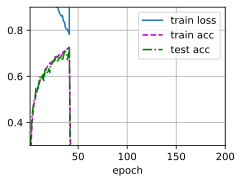

In [ ]:

# Define the model
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, K, kernel_size=3, stride=1, padding=1, pooling=False):
        super(Block, self).__init__()
        # linear layer
        self.linear = nn.Linear(in_channels, K)
        self.K = K

        # K number of conv and bn layers
        self.convs = nn.ModuleList([nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
                                   for _ in range(K)])

        self.bns = nn.ModuleList([nn.BatchNorm2d(out_channels) for _ in range(K)])
        self.relu = nn.ReLU()
        if pooling:
            self.pool = nn.MaxPool2d(2)
        else:
            self.pool = None

    def forward(self, x):
        # spartial average pooling
        a = nn.AvgPool2d(x.shape[2:])(x)
        a = self.relu(self.linear(a.view(a.shape[0],-1)))

        out = 0
        for i in range(self.K):
            o = self.convs[i](x)
            o = self.bns[i](o)
            out += self.relu(o)
            p = a[:, i].view((a.shape[0],1,1,1))
            out += torch.mul(p, o)
        if self.pool is not None:
            out = self.pool(out)
        return out

class Backbone(nn.Module):
    def __init__(self, n_blocks, n_channels, Ks):
        super(Backbone, self).__init__()
        self.blocks = nn.ModuleList([nn.Sequential(
            Block(n_channels[i], n_channels[i+1], Ks[i]),

        ) for i in range(n_blocks)])


    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


class Classifier(nn.Module):
    def __init__(self, n_classes, n_channel):
        super(Classifier, self).__init__()
        self.dropout = nn.Dropout(p=0.4)
        self.fc1 = nn.Linear(n_channel, n_classes)

    def forward(self, x):
        x = nn.AvgPool2d(x.shape[2:])(x)
        x = self.dropout(x)
        x = self.fc1(x.view(x.shape[0], -1))
        return x

class Model(nn.Module):
    def __init__(self, n_blocks, n_channels, n_classes, Ks):
        super(Model, self).__init__()
        self.backbone = Backbone(n_blocks, n_channels, Ks)
        self.classifier = Classifier(n_classes, n_channels[-1])

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

# Define the model parameters
n_blocks = 3
n_channels = [3, 32, 64, 128]
Ks = [4, 4, 4]

n_classes = 10

# initialize the model
model = Model(n_blocks, n_channels, n_classes, Ks).to(device)

# Define the loss and optimizer
criterion = nn.CrossEntropyLoss()
l2_regularization_strength = 0.00001
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0001, amsgrad=False)


from torchsummary import summary
num_epochs = 200
print(model)
# def updater(batch_size):
#     return optimizer.step()
train_ch3(model, train_loader, test_loader, criterion, num_epochs, optimizer, device)

In [ ]:
evaluate_accuracy(model, test_loader)